# Financial market analysis
### Authors: Daniel Kłodowski, Paweł Szulik

The purpose of this project was to showcase any intriguing correlations between the leaders of chosen market branches: Commodities, Crypto, Forex and Indexes. Our another goal, was to see how each of the instruments reacted subsequently to major economical and political events. Lastly we wanted to simulate a custom investing strategy and see which instruments would turn out to be the most profitable in the end.

---

### Data load

---

Firstly we load our data, using specially dedicated class - DataManager.

In [1]:
import pandas as pd
import src.data_loader as dl
import src.analytics as aly
import src.plotting as pl
from IPython.display import display

data = dl.DataManager('../data')
data.load_everything()

open    Brent Crude Oil    float64
high    Brent Crude Oil    float64
low     Brent Crude Oil    float64
close   Brent Crude Oil    float64
volume  Brent Crude Oil    float64
                            ...   
high    VIX                float64
low     VIX                float64
close   VIX                float64
volume  VIX                float64
vwap    VIX                float64
Length: 162, dtype: object


### 1. Market leaders data overview

---

At the beginning, key financial instruments relevant to the study were selected from the dataset, including Bitcoin, Gold, Brent Crude Oil, S&P 500, EURO STOXX 50, and USD/PLN. Daily percentage price changes were then computed based on closing prices from consecutive trading days.

In [2]:
selected = ["Bitcoin", "Gold", "Brent Crude Oil", "S&P 500", "EURO STOXX 50", "USDPLN"]
returns_sel = data.close_returns[selected].dropna()
close_prices_sel = data.close_prices[selected].dropna()

In the first stage, the key descriptive statistics for daily price changes were computed, including the mean, standard deviation, minimum, maximum, kurtosis, and skewness, among others.

In [3]:
returns_sel.describe().style.apply(pl.no_style).format("{:.3f}")

,Bitcoin,Gold,Brent Crude Oil,S&P 500,EURO STOXX 50,USDPLN
count,3069.000,3069.000,3069.000,3069.000,3069.000,3069.000
mean,0.523,0.035,0.093,0.058,0.051,0.003
std,5.818,1.063,2.170,1.081,1.238,0.777
min,-38.812,-11.386,-24.404,-9.511,-12.401,-4.011
25%,-1.473,-0.472,-1.010,-0.382,-0.571,-0.447
50%,0.146,0.036,0.135,0.074,0.069,-0.008
75%,2.149,0.588,1.147,0.574,0.673,0.427
max,123.881,6.070,21.019,9.515,9.236,5.040


In [4]:
returns_sel.index.min().strftime("%Y-%m-%d"), returns_sel.index.max().strftime("%Y-%m-%d")

('2009-10-06', '2026-03-04')

The data cover 3 069 days after removing missing values, spanning from 2009-10-06 to 2026-03-04.
The average daily price change is slightly above zero in each case.
Bitcoin — the main cryptocurrency — exhibits the highest volatility, followed by Brent crude oil. Bitcoin also shows the most extreme price movements, with Brent oil coming second. The least volatile asset is the USD/PLN currency pair.

The means that are significantly different from zero at the 5% significance level are highlighted in color below.

In [5]:
mean = aly.mean_significance(returns_sel)
display(pd.DataFrame(mean["mean"])
 .style.apply(
    pl.highlight_significant(mean["p_value"], lvl=0.05), axis=None), )

,mean
Bitcoin,0.523298
Gold,0.035204
Brent Crude Oil,0.092660
S&P 500,0.058010
EURO STOXX 50,0.050536
USDPLN,0.003177


The “win rate,” representing the percentage of days with a positive return, was also calculated.

In [6]:
win_r = aly.sign_test(returns_sel, alternative='greater')
(pd.DataFrame(win_r["win_rate"])
 .style.apply(
    pl.highlight_significant(mean["p_value"], lvl=0.05), axis=None))

,win_rate
Bitcoin,52.297165
Gold,52.557836
Brent Crude Oil,53.144347
S&P 500,54.838710
EURO STOXX 50,53.372434
USDPLN,49.527533


Bitcoin, oil, and equity indices have a positive average daily return (significantly different from zero). Moreover, they exhibit a statistically significant tendency to have positive daily returns more often than negative ones, indicating that the market experienced more periods of growth than decline.

In [7]:
returns_sel.kurtosis().rename("kurtosis - 3")

Bitcoin            81.843542
Gold                7.667030
Brent Crude Oil    12.217253
S&P 500            10.431578
EURO STOXX 50       7.126645
USDPLN              3.043592
Name: kurtosis - 3, dtype: float64

In [8]:
returns_sel.skew().rename("skewness")

Bitcoin            4.561607
Gold              -0.664950
Brent Crude Oil    0.056974
S&P 500            0.059590
EURO STOXX 50     -0.354205
USDPLN             0.305801
Name: skewness, dtype: float64

The distributions exhibit heavy tails, with Bitcoin showing a clearly stronger effect than the other assets. This implies that Bitcoin, as well as Brent crude oil and the S&P 500, have a systematically higher probability of extreme movements than would be expected under a normal distribution.
Moreover, Bitcoin’s daily price changes are positively skewed, indicating a higher frequency of large positive outliers. The opposite pattern is observed for gold — although less pronounced — where negative extreme movements occur more frequently.

### 2. Market correlation analysis

---

Below is the Pearson correlation matrix of returns for various financial instruments.

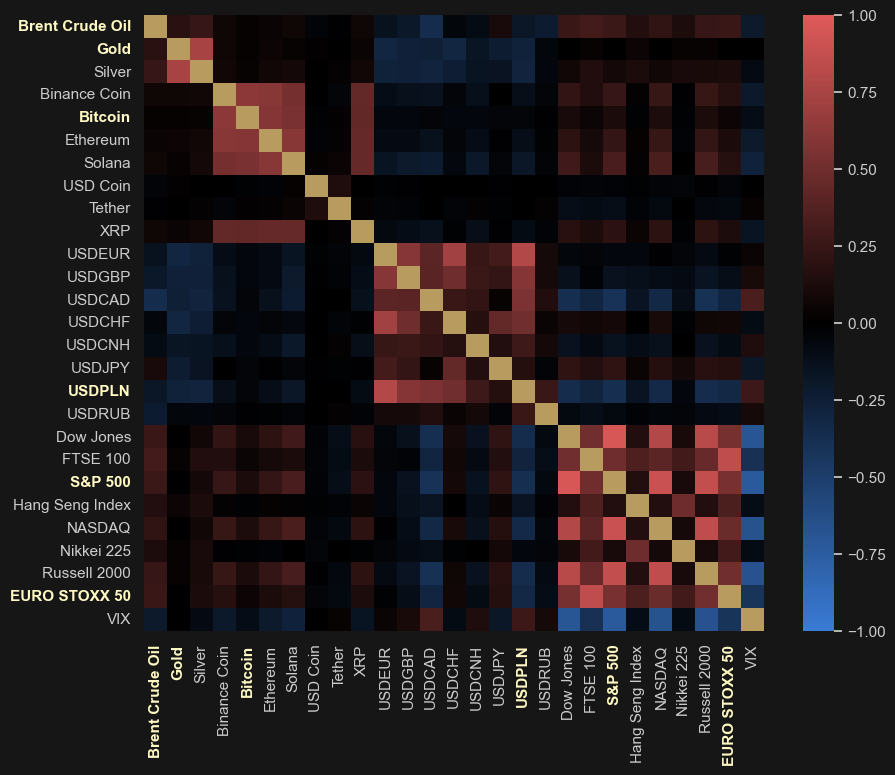

In [9]:
returns = data.close_returns

pear_cor, pear_p_vals = aly.correlations(returns, "pearson")
pl.heatmap_corr(pear_cor, highlight=selected)

The heatmap above clearly reveals distinct rectangular patterns aligned along the diagonal. This indicates that assets within the same category tend to be strongly correlated with one another. Consequently, from a portfolio diversification perspective, it is advisable to include assets from different categories.
Among the more pronounced relationships, a negative correlation can be observed between the VIX index and most of the analyzed assets. This suggests that the index effectively captures prevailing market sentiment. When the VIX rises, it is typically accompanied by simultaneous declines in the prices of various assets. Interestingly, this pattern does not hold for gold, which shows no significant correlation with the VIX, not for the USD/PLN exchange rate, which exhibits a slight positive correlation.
Cryptocurrencies show no significant relationship with commodities.

It should also be noted that all instruments (with the exception of non-U.S. indices) are linked to the U.S. dollar, which naturally implies that they will also be correlated with one another. The second observation is that the matrix above covers a noticeably shorter time span, due to the limited historical data available for some cryptocurrencies.

### 3. Market leaders analysis

---

In the next step, Pearson and Spearman correlations were analyzed for the financial instruments selected at the beginning of the study. Values highlighted in color are statistically significant at the 5% significance level.

In [10]:
spear_cor, spear_p_vals = aly.correlations(returns_sel, "spearman")
(spear_cor.style.format("{:.3f}")
 .apply(pl.highlight_significant(spear_p_vals.loc[selected, selected], lvl=0.05), axis=None))

,Bitcoin,Gold,Brent Crude Oil,S&P 500,EURO STOXX 50,USDPLN
Bitcoin,1.000,0.062,0.044,0.144,0.077,-0.082
Gold,0.062,1.000,0.130,0.043,0.004,-0.304
Brent Crude Oil,0.044,0.130,1.000,0.261,0.229,-0.149
S&P 500,0.144,0.043,0.261,1.000,0.547,-0.318
EURO STOXX 50,0.077,0.004,0.229,0.547,1.000,-0.201
USDPLN,-0.082,-0.304,-0.149,-0.318,-0.201,1.000


At first glance, most pairs appear to be statistically significantly correlated, although the strength of these correlations is generally rather weak. The Spearman correlation indicates that gold is the only asset that does not exhibit a monotonic relationship with the EURO STOXX 50 index.
The strongest positive relationship is observed between the S&P 500 and the EURO STOXX 50 indices; however, despite being the strongest, the correlation coefficient is still only around 0.55.

In [11]:
pear_cor, pear_p_vals = aly.correlations(returns_sel, "pearson")
(pear_cor.style.format("{:.3f}")
 .apply(pl.highlight_significant(pear_p_vals.loc[selected, selected], lvl=0.05), axis=None))

,Bitcoin,Gold,Brent Crude Oil,S&P 500,EURO STOXX 50,USDPLN
Bitcoin,1.000,0.028,0.028,0.121,0.056,-0.049
Gold,0.028,1.000,0.140,0.070,0.027,-0.246
Brent Crude Oil,0.028,0.140,1.000,0.287,0.242,-0.133
S&P 500,0.121,0.070,0.287,1.000,0.578,-0.366
EURO STOXX 50,0.056,0.027,0.242,0.578,1.000,-0.301
USDPLN,-0.049,-0.246,-0.133,-0.366,-0.301,1.000


Moreover, Pearson correlation indicates statistically significant linear relationships for most of the analyzed assets. The exception is Bitcoin, which does not exhibit a significant linear correlation with either gold or Brent crude oil.

Below are the estimated regression slope coefficients along with their statistical significance tests at the 5% level. The columns represent the dependent variables (y), while the rows represent the explanatory variables (x).

In [12]:
reg, reg_pvals = aly.regression(returns_sel)
(reg.style.format("{:.3f}")
 .apply(pl.highlight_significant(reg_pvals.loc[selected, selected], lvl=0.05), axis=None))

,Bitcoin,Gold,Brent Crude Oil,S&P 500,EURO STOXX 50,USDPLN
Bitcoin,1.000,0.005,0.010,0.022,0.012,-0.007
Gold,0.152,1.000,0.286,0.071,0.032,-0.180
Brent Crude Oil,0.074,0.069,1.000,0.143,0.138,-0.048
S&P 500,0.649,0.069,0.576,1.000,0.662,-0.263
EURO STOXX 50,0.265,0.023,0.423,0.504,1.000,-0.189
USDPLN,-0.368,-0.337,-0.371,-0.509,-0.480,1.000


Among the strongest relationships are the S&P 500–EURO STOXX 50 pair and the S&P 500–Bitcoin pair. When the S&P 500 increases by 1%, the EURO STOXX 50 is expected to rise by approximately 0.66%, while Bitcoin is expected to rise by approximately 0.65%.

The strongest negative relationships are observed for the USD/PLN–S&P 500 and USD/PLN–EURO STOXX 50 pairs: a 1% increase in USD/PLN is associated with an approximately 0.51% decrease in the S&P 500, while the EURO STOXX 50 is expected to decrease by approximately 0.48%.

Below are the distributions of daily price changes, after removing outliers using a 3 × interquartile range (IQR) threshold.

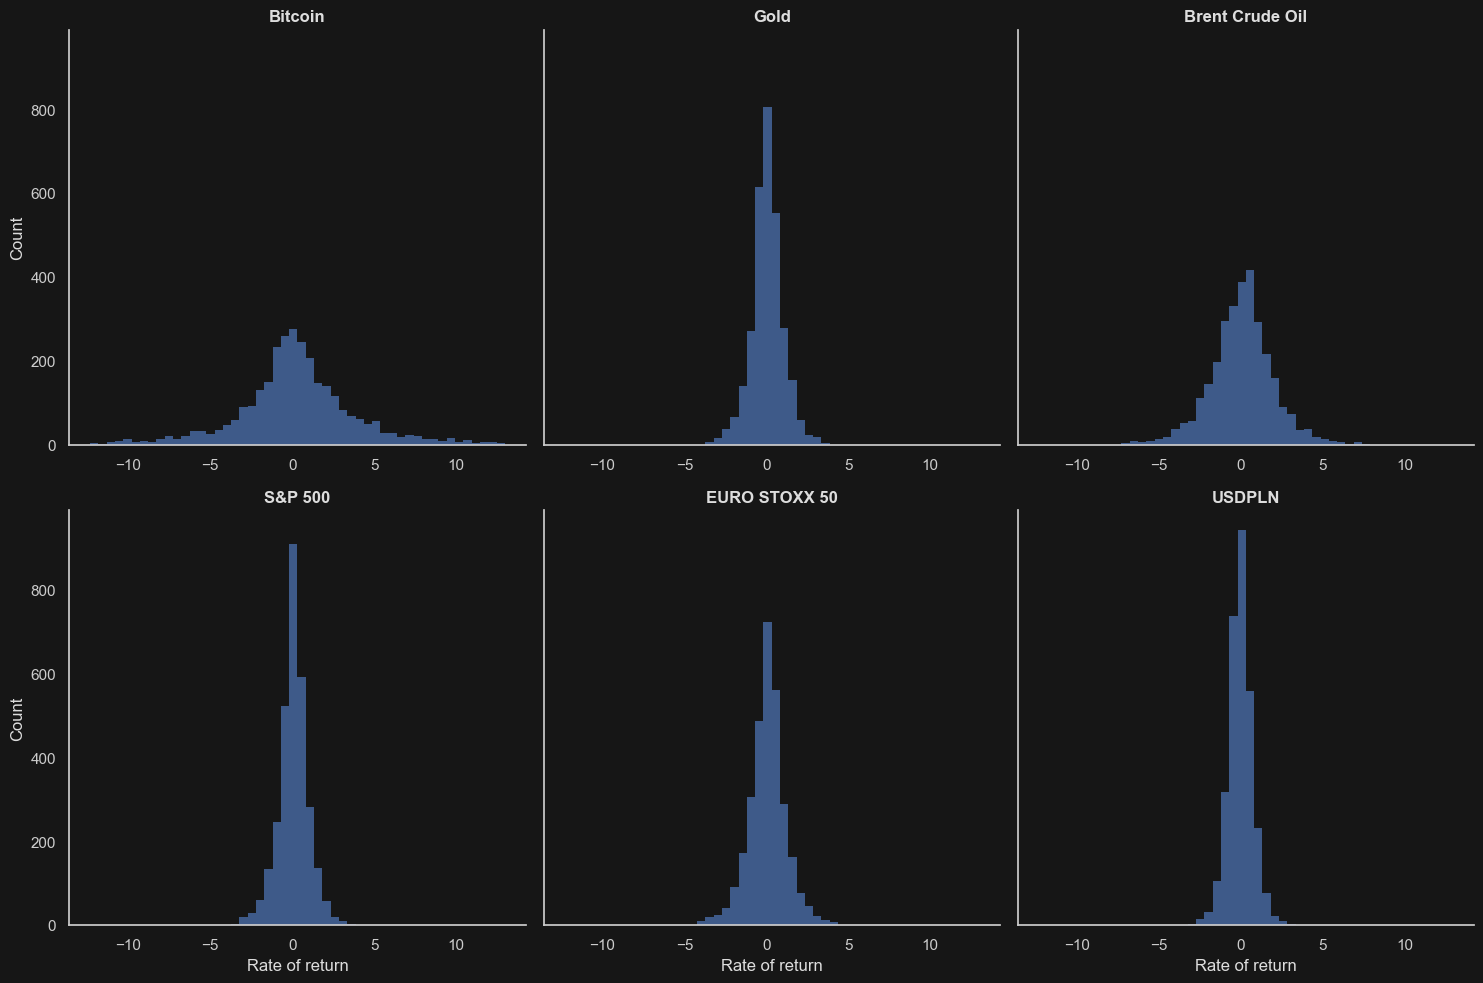

In [13]:
pl.price_change_distributions(aly.remove_outliers(returns_sel, IQR_multiplier=3))

As previously noted, the distributions deviate significantly from normality, exhibiting heavy tails (a high presence of extreme values) and a strong concentration of observations around zero.


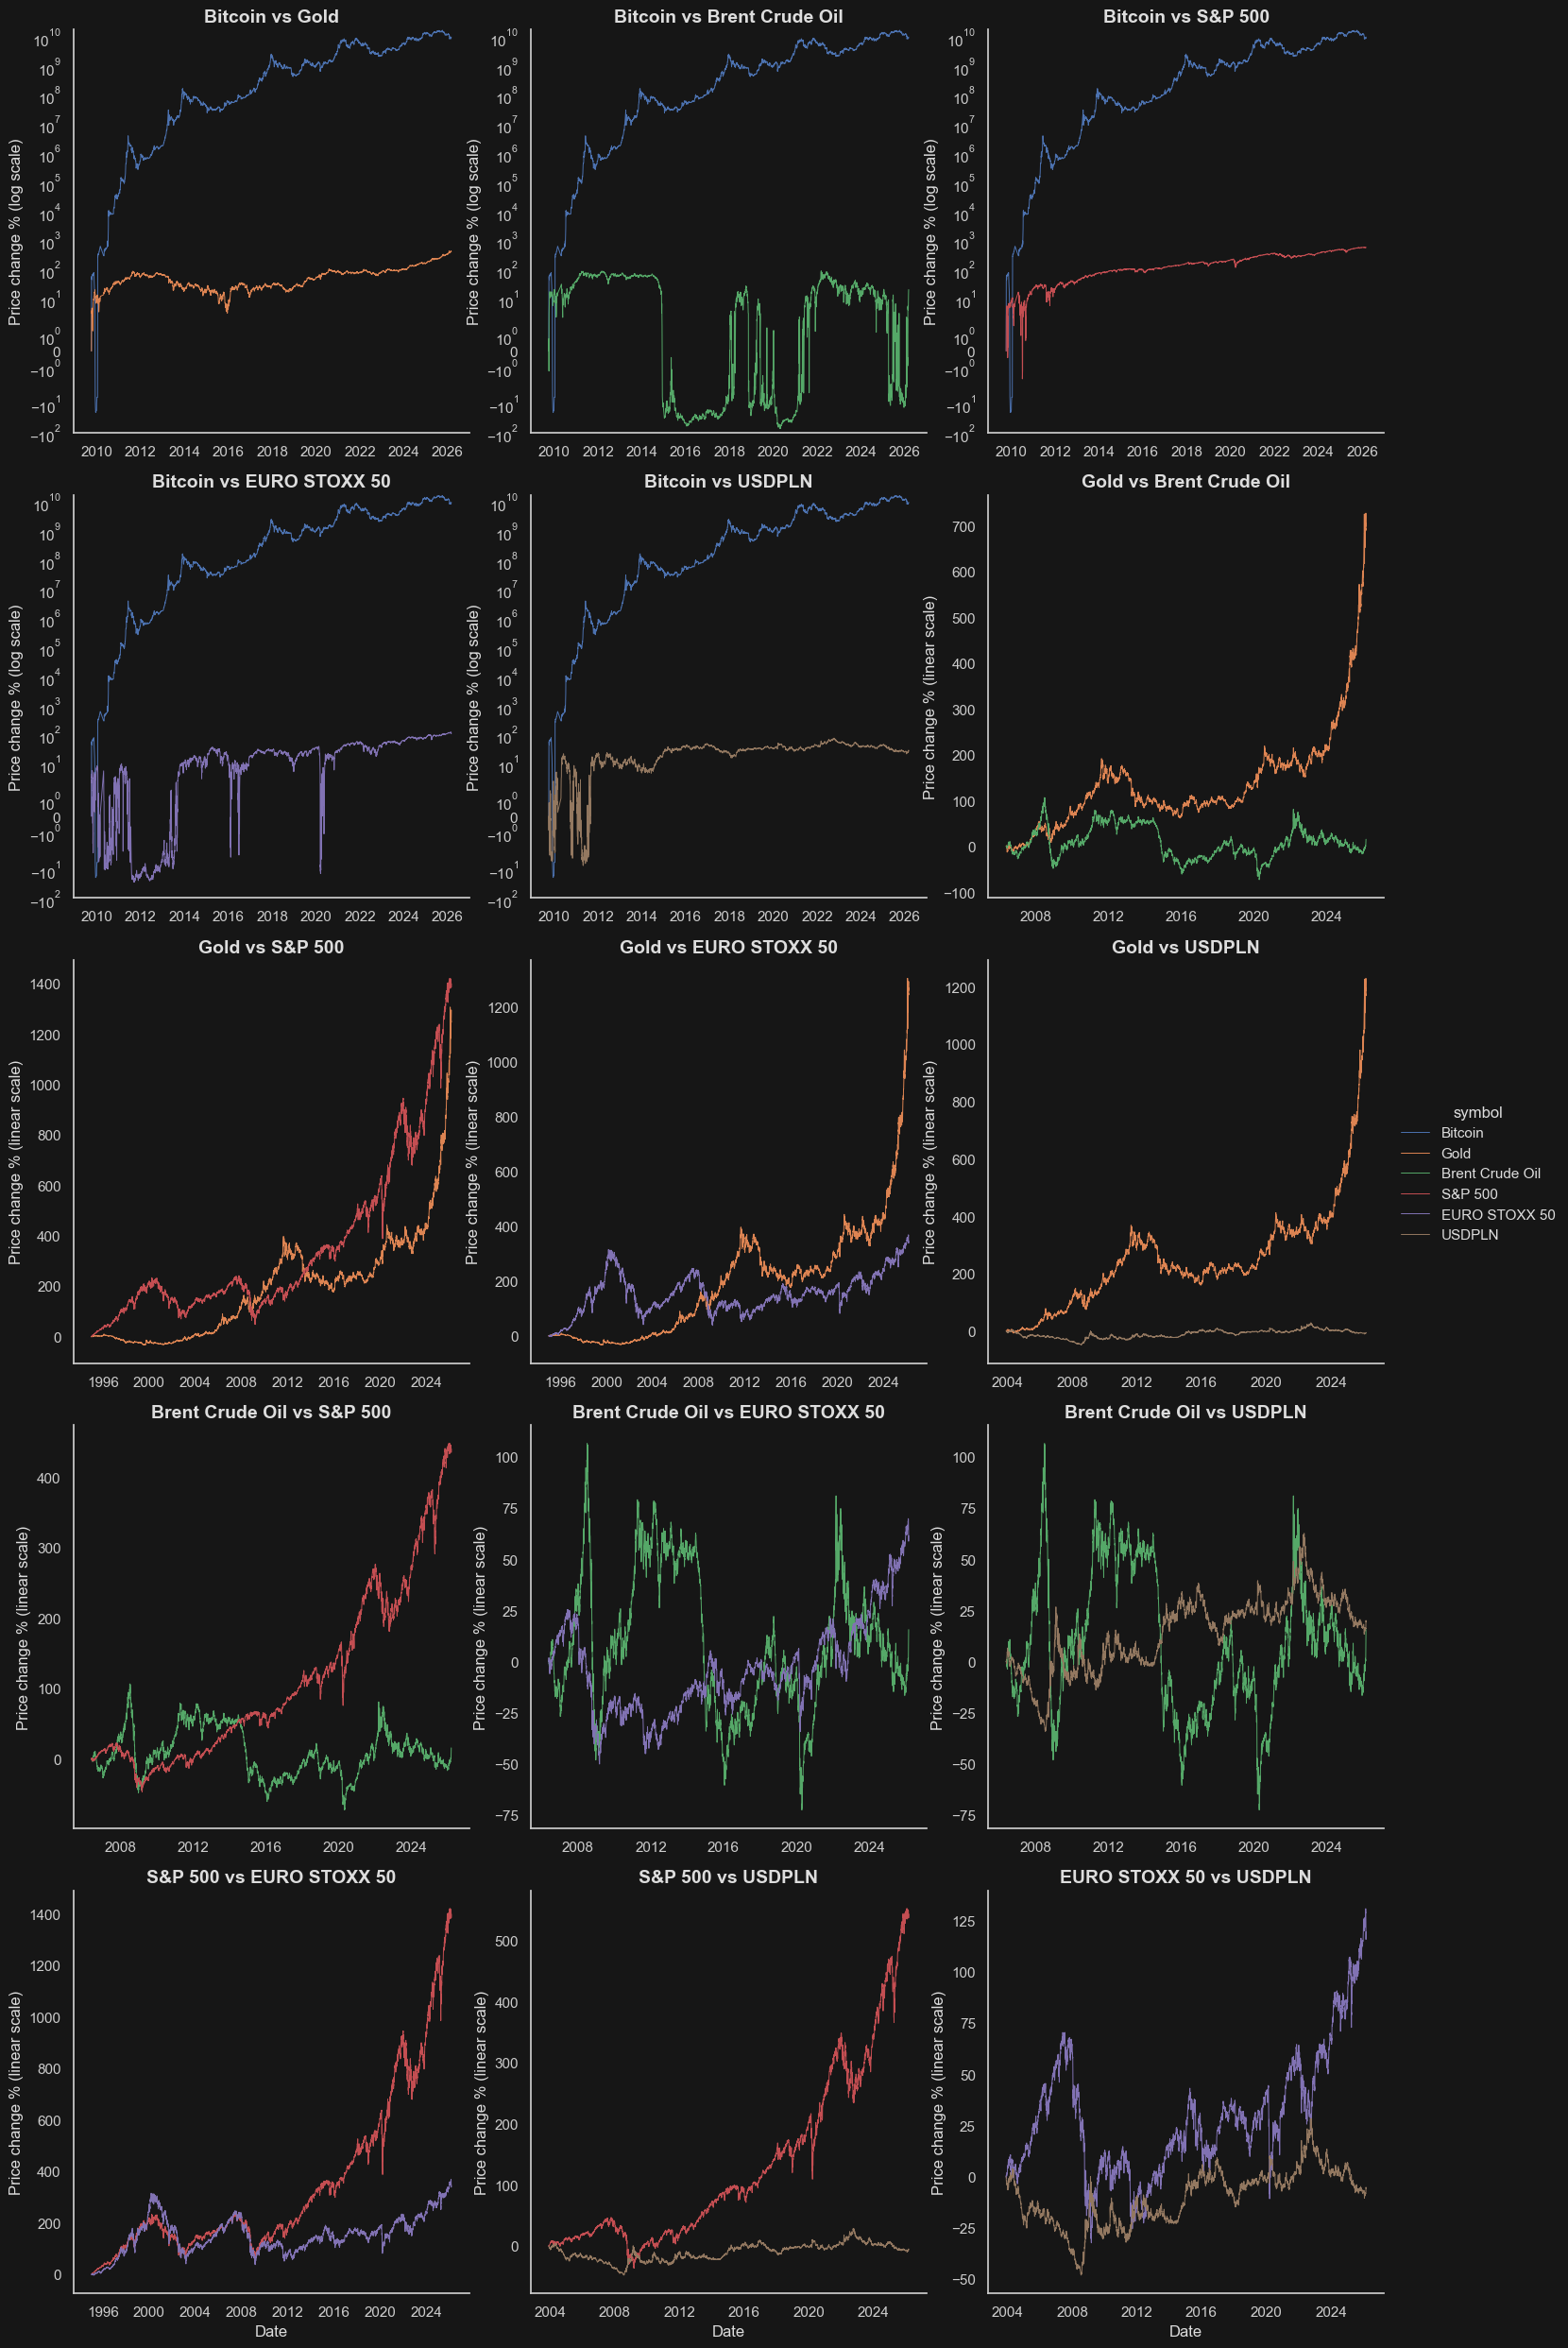

In [14]:
combinations = aly.make_pairs(selected)

pl.comparison_plot(data.close_prices, combinations)


Conclusions from the comparison:
- As expected, Bitcoin's extreme percentage return rates are asymetrical when compared with other instruments. When Bitcoin was highly rising, other instruments were stable or their prices were slightly falling. It shows how unique and risky Bitcoin really is.
- When we look at the pair of Gold and Brent Crude Oil, for the most part, they had similar trends, but with major world crisis as Covid-19 and Russias invasion on Ukraine - their prices were changing differently - Gold was rising and Oil was getting cheaper. We can conclude that when markets are under major pressure, demand for Gold and Oil is divergent.
- Brent Crude Oil, when compared to indexes, characterise with negative correlation. Companies usually prosper when energy costs decrease.
- S&P 500 VS EURO STOXX 50: In the past, they were highly correlated, but since around 2012, American companies have noted a significant growth and started outperforming the European market.
- S&P 500 VS USDPLN: When S&P 500 was rising, USDPLN was rather stable, but when index was met with significant falls in prices, USDPLN would rise.

### 4. Trends and volatility

---

To analyze the volatility of the selected assets, rolling standard deviations based on the last 60 days were visualized.

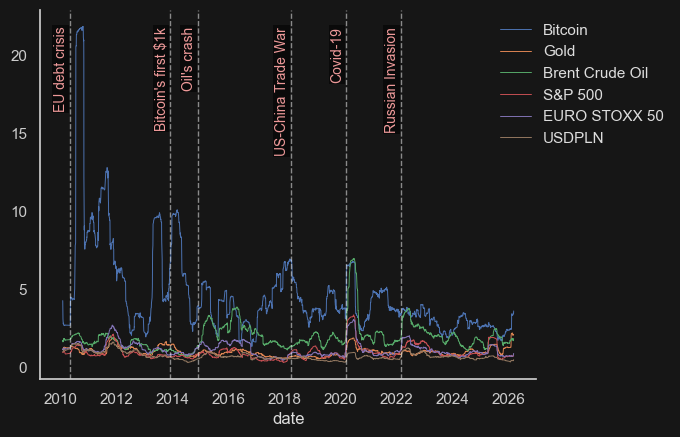

In [15]:
pl.rolling_volatility_plot(returns_sel, window=60)

Bitcoin exhibits the highest volatility among the analyzed assets; however, a gradual downward trend in its volatility can be observed. This may be attributed, among other factors, to the increasing number of market participants and the growing market capitalization, which reduces the impact of individual investors on price movements.
Brent crude oil, on the other hand, shows a mild upward trend in volatility. For the remaining instruments, volatility fluctuates around a relatively stable level.
The highlighted events generally led to increases in market volatility. This is particularly evident during the COVID-19 pandemic, when a sharp spike in volatility occurred across all analyzed assets.
It is also worth noting that Bitcoin did not always respond with increased volatility in the same direction as other instruments. For instance, following the onset of the U.S.–China trade war in 2018, its volatility even stabilized.

To see the direction of instruments trend, we'll analyze their Simple Moving Average. Especially the impact of significant events and which Instrument trends they have varied. Same as with percentage change comparison, for Bitcoin we'll use the logarythimc scale.

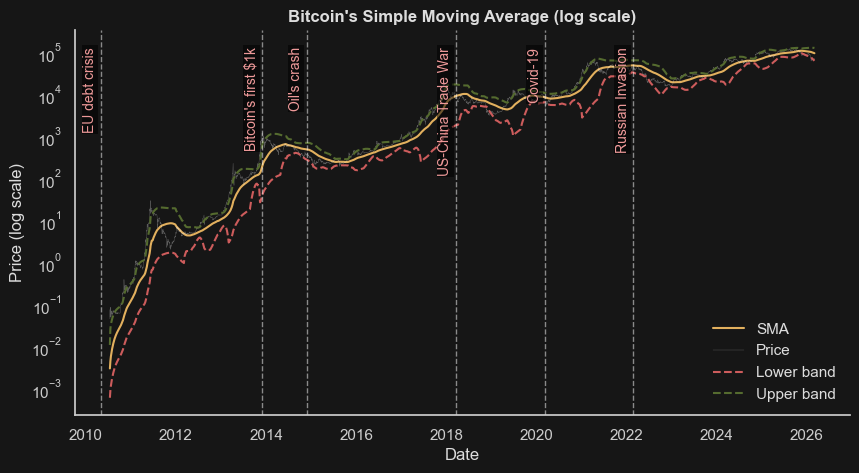

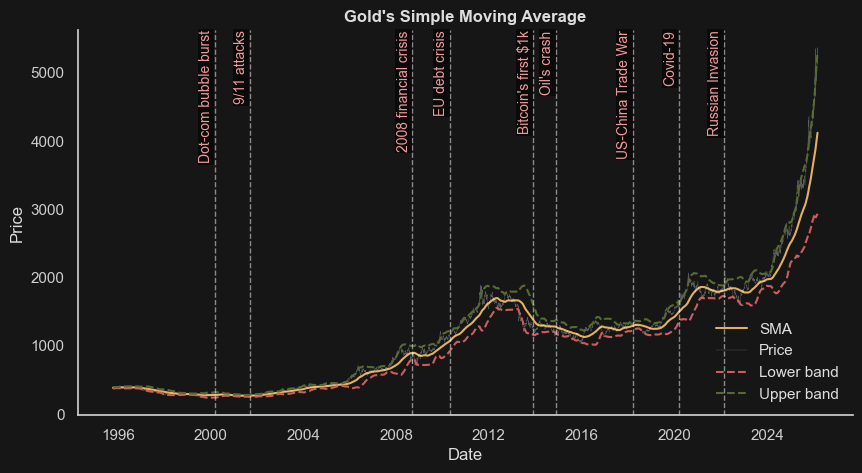

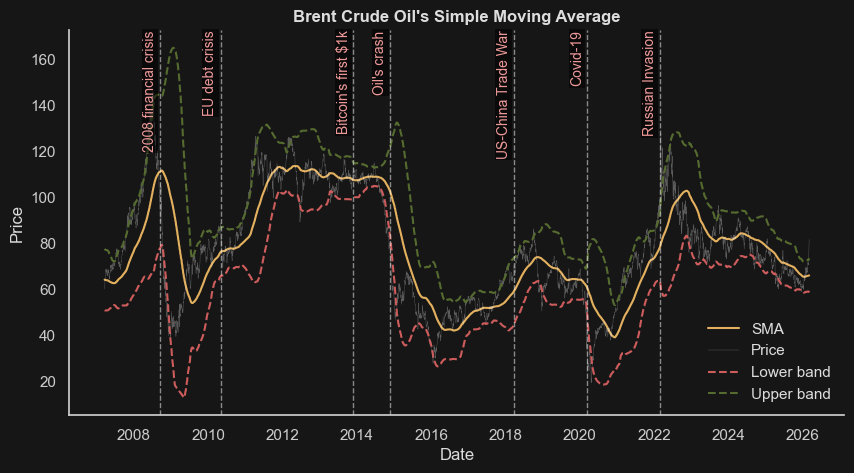

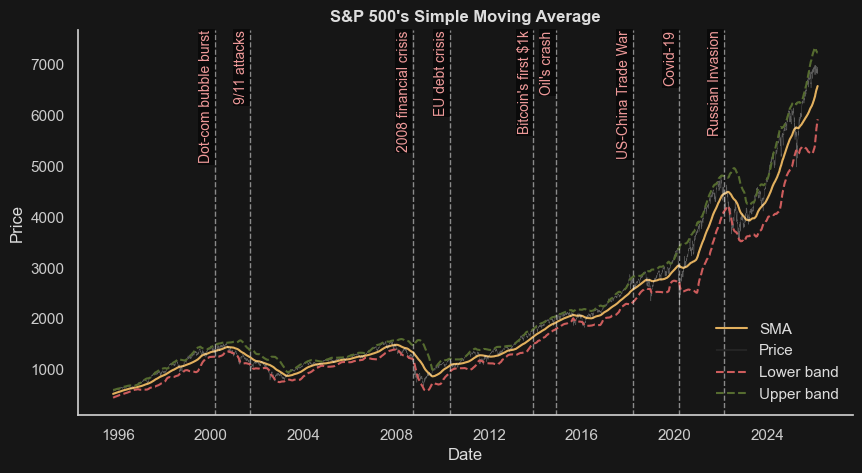

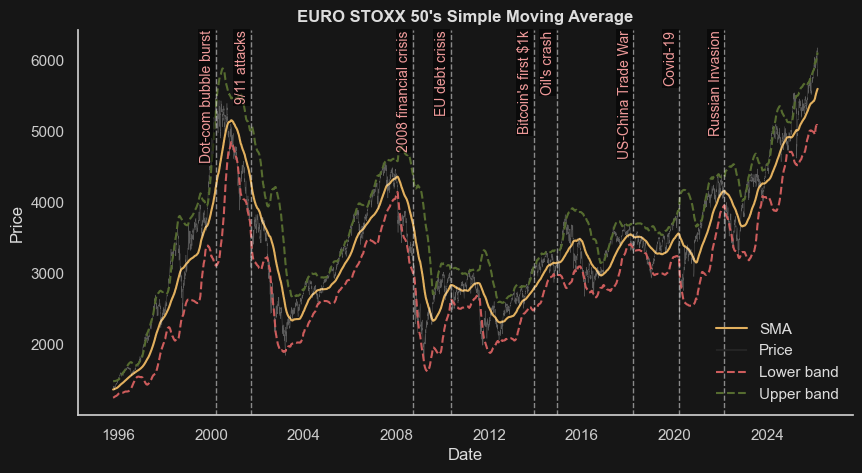

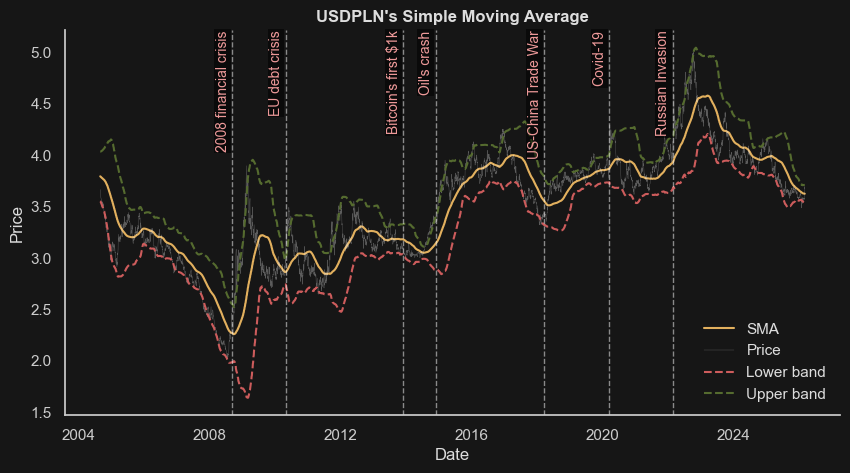

In [16]:
pl.sma_change_plot(data.close_prices, selected)

Events and impact they made:
- 'Dot-com bubble burst' - & '9/11 attacks' - Dot-com bubble burst and 9/11 attacks generally caused a decreasing trend of S&P 500 and EURO STOXX 50 - market steering clear from the technological sector,
- '2008 financial crisis' - Crash on Oil and indexes, brief decrease of Gold prices, then high rising trend, USDPLN strengthens - general panic where investors started selling everything, even gold - that's why its trend was unstable,
- 'EU debt crisis' - it didn't affect Bitcoin which was at still its beginnigs. Oil and Gold were rising, EURO STOXX 50 noted decreasing trend - Gold was investors security in the time of uncertainty,
- 'Bitcoin's first $1k' - Bitcoins continuous rising trend, Gold starts prices start to drop - People realize that Bitcoin might be an alternative to gold,
- 'Oil's crash' - Extreme Oil Crash, indexes were thriving - cheap energy decreased costs for companies which let them grow,
- 'US-China Trade War' - Bitcoins growth stops, Oil prices fall, indexes were thought to drop too, but Trumps taxes cuts helped them maintain their growth,
- 'Covid-19' - Everything crashed at first due to global pandemic, Bitcoin and gold as a security, were growing,
- 'Russian Invasion' - War caused gold and oil prices to rise (supply shock), indexes noted a fall caused by inflation and risk. USDPLN was at its peak, as Poles were neighbors to the conflict.

Below is a summary of the longest drawdown periods, measured as the time taken for prices to recover to their previous historical highs, covering the period from 2009-10-06 to 2026-03-04.

In [17]:
aly.longest_drawdown(close_prices_sel)

,asset,start,end,length
0,Bitcoin,2013-12-05,2017-03-01,1182
1,Gold,2011-08-23,2020-07-23,3257
2,Brent Crude Oil,2011-04-11,2022-03-07,3983
3,S&P 500,2022-01-04,2024-01-18,744
4,EURO STOXX 50,2015-04-14,2020-02-11,1764
5,USDPLN,2022-10-11,2026-03-04,1240


The S&P 500 experienced the shortest bear market period, taking just over two years to recover to its previous peak. This highlights the strength and rapid growth of the U.S. economy. In contrast, Brent crude oil recorded the longest recovery period, followed by gold, at approximately 11 and 9 years, respectively.

### 5. Long term hypothetical investment strategy

---

As a last section of our project, we wanted to simulate an investing strategy one of us was using, since 2024-10-01 up until now. The strategy was to invest 500PLN at the beginning of each month into the S&P 500 index, in order to have some savings and not have money lying around on the bank account, slowly losing its value. The simulation didn't include transaction costs.

In [18]:
from src.investment_strategy_simulation import investment_strategy_sim
symbols_list = ["Brent Crude Oil", "Gold", "Silver", "Bitcoin", "Ethereum", "USDPLN", "Dow Jones", "S&P 500",
     "NASDAQ", "Russell 2000", "VIX"]

investment_strategy_sim(data.close_prices, symbols_list)


,symbol,Total invested PLN,Final investment value,Final profit,Final profit_perc
2,Silver,9000.0,18264.05,9264.05,102.93
1,Gold,9000.0,13248.05,4248.05,47.20
0,Brent Crude Oil,9000.0,10399.41,1399.41,15.55
9,Russell 2000,9000.0,10078.64,1078.64,11.98
10,VIX,9000.0,9966.51,966.51,10.74
8,NASDAQ,9000.0,9830.26,830.26,9.23
7,S&P 500,9000.0,9662.05,662.05,7.36
6,Dow Jones,9000.0,9538.17,538.17,5.98
5,USDPLN,9000.0,8502.06,-497.94,-5.53
3,Bitcoin,9000.0,7154.48,-1845.52,-20.51


After 18 months the return rate was around 8%, while the investing wasn't conducted identically to the strategy (different deposit dates, sometimes more money was invested), simulation results were similar.
 The simulation proved to be the most effective if one was to invest in commodities such as Silver, Gold or Oil. Indexes return rates were rather to be expected ~10%. What was surprising, that even though crypto prices were at their peak in the last 18-months, the return rate was the lowest, and would lose about 20%. It may be due to the fact, that cryptos would be purchased suboptimally at their highs.

### Summary

---

Most significant conclusions from the analysis:
- **Assets characteristics**: Bitcoin has turned out to be having the unique risk profile, its volatility was the highest out of the chosen leaders, it had a positive skewness with "heavy tails" in its distribution which makes it stand out from other assets.
- **Correlation dynamics**: Indexes are highly correlated, VIX as a fear indicator, turned out to have negative correlation with the majority of the assets (except for Gold). American marked outperformed European one, which started after 2012.
- **Instruments reaction on Events**: SMA analysis proved that instruments have various reactions when met with crisis. While Oil prices significantly dropped with demand collapses, Bitcoin's and Gold's value gained, as inflation and uncertainty protectors.
- **Investing**: In the analyzed timespan (2024-10-01 - 2026-03-04), while using the custom strategy, Silver and Gold proved to be the most profitable. While crypto prices reached their peak, the strategy unfortunately involved investing in them while at their highs, hence the negative rate of return.
- **Regeneration**: Drawdown analysis showed, that American markets tend to recover the fastest, while commodities such as gold or oil require disproportionately more time to return to their historical peaks.